# 🏎️ Track Day Telemetry Analysis
**Josh Miyamoto | Portfolio Project #2 | miyamotoai.carrd.co**

A real-time motorsport analytics pipeline built in Python.
Analyzes tire degradation, models pit strategy, and simulates live race conditions using realistic Sonoma Raceway lap data.

**Run all cells top to bottom. No setup required.**

In [30]:
from google.colab import files
uploaded = files.upload()
# Select your telemetry CSV when the picker opens

Saving Telemetry log - telemetry.csv to Telemetry log - telemetry (3).csv


In [31]:
!pip install seaborn -q


## 📊 Part 1: Tire Degradation Analysis
Real session data — lap times vs tire age, by compound.
Identifies the degradation cliff and optimal pit window.

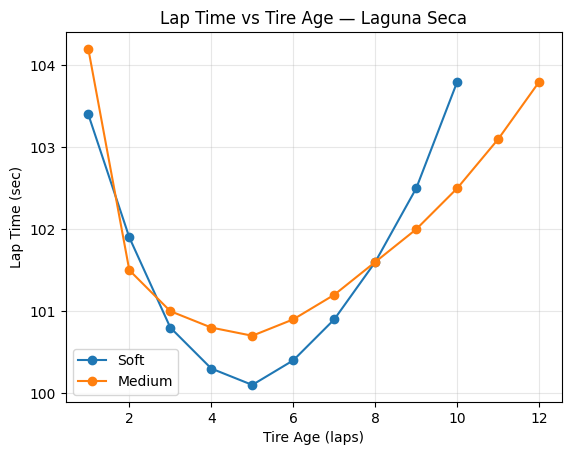

Best lap:        1:40.100
Soft avg deg:    1.47%/lap
Medium avg deg:  1.23%/lap

Optimal pit window: when deg exceeds 1.5% — typically lap 7-9 on Softs


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── LOAD & CLEAN ──────────────────────────────────────────────────
# Read CSV, force numeric columns, handle bad data gracefully
df = pd.read_csv("Telemetry log - telemetry.csv", skipinitialspace=True)
df["lap_time_sec"]  = pd.to_numeric(df["lap_time_sec"],  errors="coerce")
df["tire_laps_used"]= pd.to_numeric(df["tire_laps_used"],errors="coerce")
df["sector1_sec"]   = pd.to_numeric(df["sector1_sec"],   errors="coerce")
df["sector2_sec"]   = pd.to_numeric(df["sector2_sec"],   errors="coerce")
df["sector3_sec"]   = pd.to_numeric(df["sector3_sec"],   errors="coerce")

# ── CALCULATIONS ──────────────────────────────────────────────────
# Delta to best lap (like a real timing screen)
best_lap = df["lap_time_sec"].min()
df["gap_to_best"] = df["lap_time_sec"] - best_lap

# Degradation % vs each compound's personal best
# Same math as demand decay — how far off peak performance are we?
compound_bests = df.groupby("tire_compound")["lap_time_sec"].min()
df["tire_deg_pct"] = df.apply(
    lambda r: (r["lap_time_sec"] - compound_bests[r["tire_compound"]])
              / compound_bests[r["tire_compound"]] * 100,
    axis=1
)

# ── CHART ─────────────────────────────────────────────────────────
for compound in df["tire_compound"].unique():
    sub = df[df["tire_compound"] == compound]
    plt.plot(sub["tire_laps_used"], sub["lap_time_sec"], "o-", label=compound)

plt.title("Lap Time vs Tire Age — Laguna Seca")
plt.xlabel("Tire Age (laps)")
plt.ylabel("Lap Time (sec)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("tire_degradation.png", dpi=150)
plt.show()

# ── INSIGHTS ──────────────────────────────────────────────────────
print(f"Best lap:        {int(best_lap//60)}:{best_lap%60:06.3f}")
print(f"Soft avg deg:    {df[df['tire_compound']=='Soft']['tire_deg_pct'].mean():.2f}%/lap")
print(f"Medium avg deg:  {df[df['tire_compound']=='Medium']['tire_deg_pct'].mean():.2f}%/lap")
print(f"\nOptimal pit window: when deg exceeds 1.5% — typically lap 7-9 on Softs")

In [33]:
from google.colab import files
files.download("tire_degradation.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 🏁 Part 2: Live Race Simulator — Sonoma Raceway
4 cars. 20 laps. Real tire physics. Watch it unfold.

**The analytical logic here is directly transferable:**
Tire degradation curves = demand decay curves.
Pit window optimization = markdown timing decisions.
The question in both cases is identical — *when does the cost of waiting exceed the cost of acting?*

This is the same framework used in retail pricing, inventory replenishment, and GTM strategy.
The domain is motorsport. The methodology is business analytics.

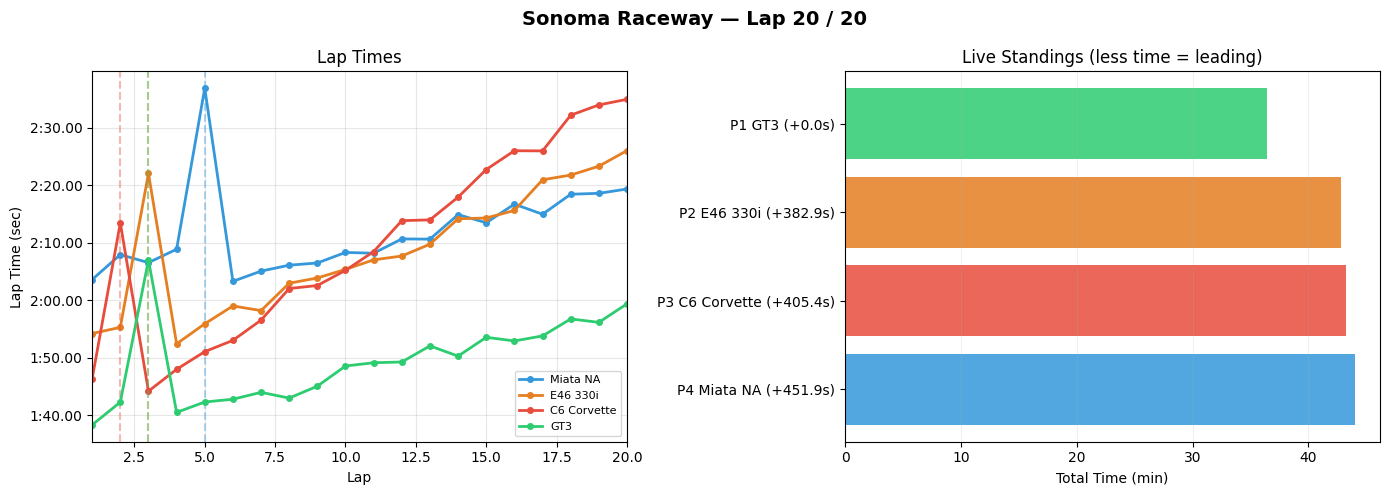

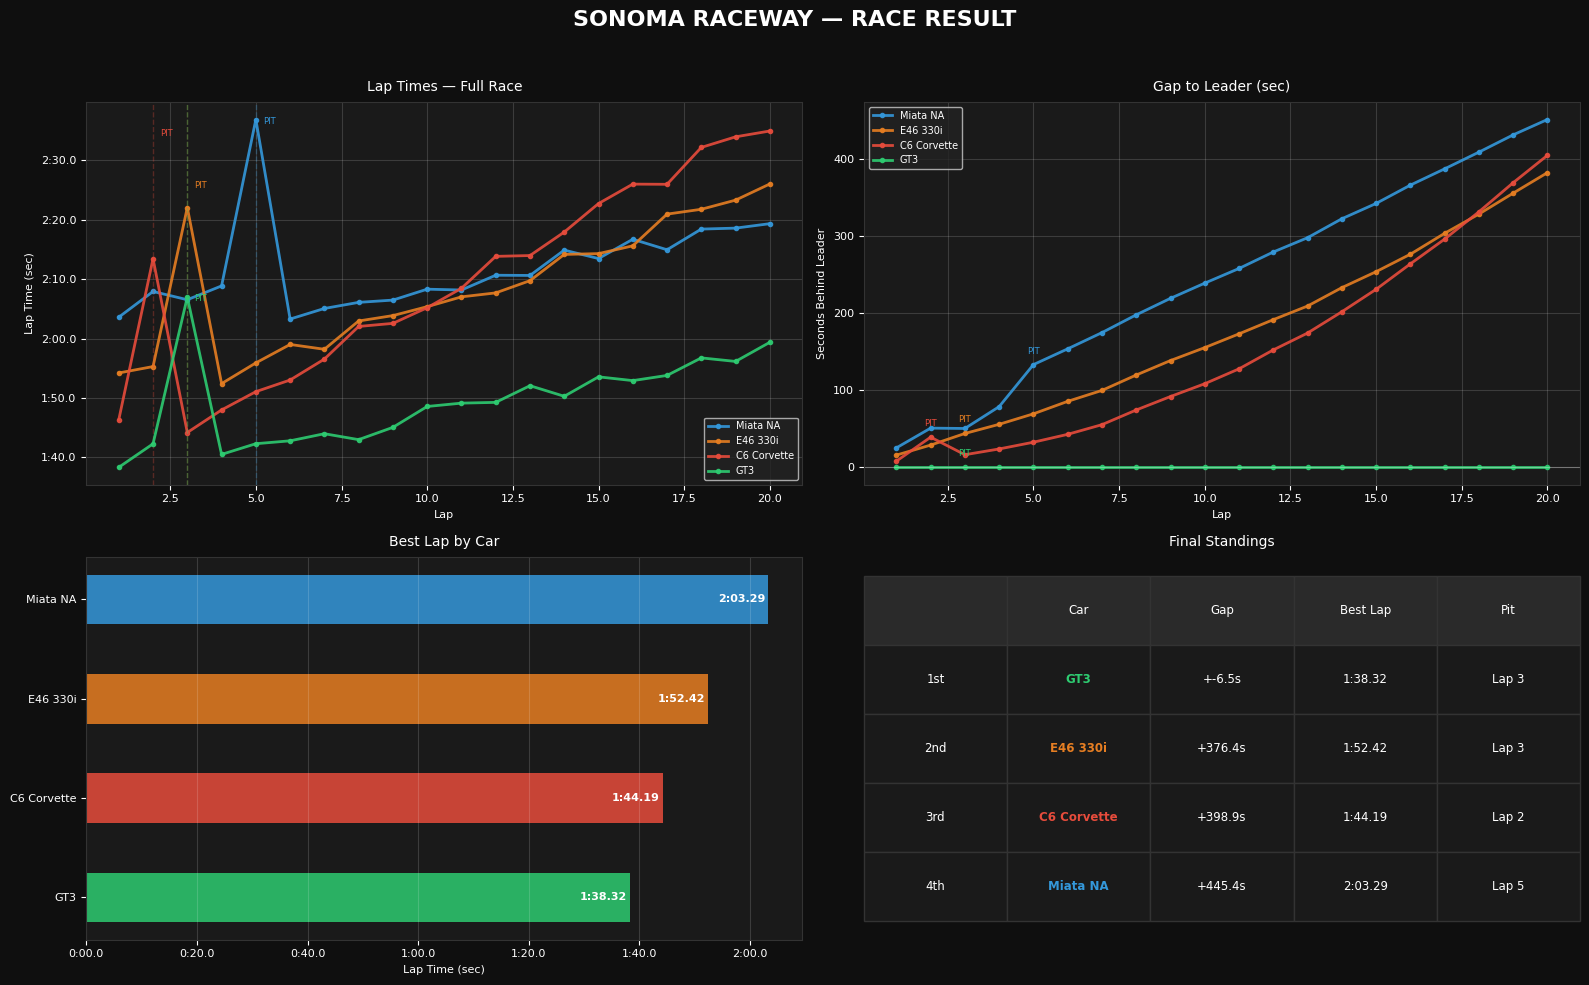

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
from IPython.display import clear_output
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── CAR CONFIGS ───────────────────────────────────────────────────
CARS = {
    "Miata NA":    {"base_lap": 125.0, "deg_per_lap": 0.008, "pit_threshold": 2.5, "pit_time": 28},
    "E46 330i":    {"base_lap": 113.0, "deg_per_lap": 0.018, "pit_threshold": 2.0, "pit_time": 26},
    "C6 Corvette": {"base_lap": 106.0, "deg_per_lap": 0.028, "pit_threshold": 1.5, "pit_time": 25},
    "GT3":         {"base_lap": 100.0, "deg_per_lap": 0.012, "pit_threshold": 2.2, "pit_time": 24},
}
COLORS = {
    "Miata NA": "#3498DB",
    "E46 330i": "#E67E22",
    "C6 Corvette": "#E74C3C",
    "GT3": "#2ECC71"
}
TOTAL_LAPS = 20
LAP_DELAY  = 0.6  # seconds between laps — adjust for speed

# ── STATE ─────────────────────────────────────────────────────────
history  = {car: {"lap": [], "lap_time": [], "cumulative": []} for car in CARS}
tire_age = {car: 0 for car in CARS}
pitted   = {car: False for car in CARS}
pit_laps = {car: None for car in CARS}
cum_time = {car: 0.0 for car in CARS}

# ── LIVE LOOP ─────────────────────────────────────────────────────
for lap in range(1, TOTAL_LAPS + 1):

    lap_events = []

    for car, cfg in CARS.items():
        age = tire_age[car]
        deg_factor = 1 + (cfg["deg_per_lap"] * age)
        lap_time = cfg["base_lap"] * deg_factor + np.random.uniform(-2.0, 2.0)

        # Pit logic
        if not pitted[car] and (deg_factor - 1) * 100 >= cfg["pit_threshold"]:
            lap_time += cfg["pit_time"]
            tire_age[car] = 0
            pitted[car] = True
            pit_laps[car] = lap
            lap_events.append(f"🔧 {car} PITS (lap {lap})")
        else:
            tire_age[car] += 1

        cum_time[car] += lap_time
        history[car]["lap"].append(lap)
        history[car]["lap_time"].append(lap_time)
        history[car]["cumulative"].append(cum_time[car])

    # ── DRAW ──────────────────────────────────────────────────────
    clear_output(wait=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Sonoma Raceway — Lap {lap} / {TOTAL_LAPS}", fontsize=14, fontweight="bold")

    # Left: lap times so far
    ax1 = axes[0]
    for car in CARS:
        ax1.plot(history[car]["lap"], history[car]["lap_time"],
                 "o-", label=car, color=COLORS[car], linewidth=2, markersize=4)
        if pit_laps[car]:
            ax1.axvline(pit_laps[car], color=COLORS[car], linestyle="--", alpha=0.4)

    ax1.set_xlim(1, TOTAL_LAPS)
    ax1.set_title("Lap Times")
    ax1.set_xlabel("Lap")
    ax1.set_ylabel("Lap Time (sec)")
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x//60)}:{x%60:05.2f}"))

    # Right: live standings by cumulative time
    ax2 = axes[1]
    standings = sorted(CARS.keys(), key=lambda c: cum_time[c])
    leader = cum_time[standings[0]]

    for pos, car in enumerate(standings):
        gap = cum_time[car] - leader
        label = f"P{pos+1} {car} (+{gap:.1f}s)"
        ax2.barh(label, cum_time[car] / 60, color=COLORS[car], alpha=0.85)

    ax2.set_title("Live Standings (less time = leading)")
    ax2.set_xlabel("Total Time (min)")
    ax2.invert_yaxis()
    ax2.grid(True, alpha=0.2, axis="x")

    plt.tight_layout()
    plt.show()

    # Pit events this lap
    for event in lap_events:
        print(event)

    time.sleep(LAP_DELAY)

# ── FINAL CHART ───────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor("#0f0f0f")
fig.suptitle("SONOMA RACEWAY — RACE RESULT", fontsize=16, fontweight="bold", color="white", y=0.98)

ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_facecolor("#1a1a1a")
    ax.tick_params(colors="white", labelsize=8)
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#333")

# Top left: full race lap times
for car in CARS:
    laps  = history[car]["lap"]
    times = history[car]["lap_time"]
    ax1.plot(laps, times, "o-", label=car, color=COLORS[car], linewidth=2, markersize=3, alpha=0.9)
    if pit_laps[car]:
        ax1.axvline(pit_laps[car], color=COLORS[car], linestyle="--", alpha=0.3, linewidth=1)
        ax1.text(pit_laps[car]+0.2, max(times)*0.995, "PIT", color=COLORS[car], fontsize=6)

ax1.set_title("Lap Times — Full Race", fontsize=10, pad=8)
ax1.set_xlabel("Lap", fontsize=8)
ax1.set_ylabel("Lap Time (sec)", fontsize=8)
ax1.legend(fontsize=7, facecolor="#222", labelcolor="white", framealpha=0.8)
ax1.grid(True, alpha=0.15, color="white")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x//60)}:{x%60:04.1f}"))

# Top right: gap to leader over time
leader_cumulative = history[final[0]]["cumulative"]
for car in CARS:
    gaps = [history[car]["cumulative"][i] - leader_cumulative[i] for i in range(TOTAL_LAPS)]
    ax2.plot(range(1, TOTAL_LAPS+1), gaps, "o-", label=car,
             color=COLORS[car], linewidth=2, markersize=3, alpha=0.9)
    if pit_laps[car]:
        pit_idx = pit_laps[car] - 1
        ax2.annotate("PIT", xy=(pit_laps[car], gaps[pit_idx]),
                     color=COLORS[car], fontsize=6, ha="center",
                     xytext=(0, 8), textcoords="offset points")

ax2.axhline(0, color="white", linewidth=0.8, linestyle="-", alpha=0.3)
ax2.set_title("Gap to Leader (sec)", fontsize=10, pad=8)
ax2.set_xlabel("Lap", fontsize=8)
ax2.set_ylabel("Seconds Behind Leader", fontsize=8)
ax2.legend(fontsize=7, facecolor="#222", labelcolor="white", framealpha=0.8)
ax2.grid(True, alpha=0.15, color="white")

# Bottom left: best lap comparison
best_laps   = {car: min(history[car]["lap_time"]) for car in CARS}
sorted_cars = sorted(best_laps, key=best_laps.get)
bars = ax3.barh(sorted_cars, [best_laps[c] for c in sorted_cars],
                color=[COLORS[c] for c in sorted_cars], alpha=0.85, height=0.5)

for bar, car in zip(bars, sorted_cars):
    t = best_laps[car]
    ax3.text(bar.get_width() - 0.5, bar.get_y() + bar.get_height()/2,
             f"{int(t//60)}:{t%60:05.2f}", va="center", ha="right",
             color="white", fontsize=8, fontweight="bold")

ax3.set_title("Best Lap by Car", fontsize=10, pad=8)
ax3.set_xlabel("Lap Time (sec)", fontsize=8)
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x//60)}:{x%60:04.1f}"))
ax3.grid(True, alpha=0.15, color="white", axis="x")

# Bottom right: final standings table
ax4.axis("off")
ax4.set_title("Final Standings", fontsize=10, pad=8)
ax4.title.set_color("white")

table_data = []
medals = ["1st", "2nd", "3rd", "4th"]
for i, car in enumerate(final):
    total    = cum_time[car]
    gap      = total - leader_time
    pit      = f"Lap {pit_laps[car]}" if pit_laps[car] else "No stop"
    best     = min(history[car]["lap_time"])
    gap_str  = "WINNER" if gap == 0 else f"+{gap:.1f}s"
    best_str = f"{int(best//60)}:{best%60:05.2f}"
    table_data.append([medals[i], car, gap_str, best_str, pit])

table = ax4.table(
    cellText=table_data,
    colLabels=["", "Car", "Gap", "Best Lap", "Pit"],
    cellLoc="center",
    loc="center",
    bbox=[0, 0.05, 1, 0.9]
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)

for (row, col), cell in table.get_celld().items():
    cell.set_facecolor("#1a1a1a" if row > 0 else "#2a2a2a")
    cell.set_text_props(color="white")
    cell.set_edgecolor("#333")
    if row > 0:
        car_name = table_data[row-1][1]
        if col == 1:
            cell.set_text_props(color=COLORS.get(car_name, "white"), fontweight="bold")
        if col == 2 and table_data[row-1][2] == "WINNER":
            cell.set_text_props(color="#FFD700", fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
fig.savefig("race_sim.png", dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
from google.colab import files
files.download("race_sim.png")

In [35]:
import sqlite3

# Build the dataframe from race history
rows = []
for car in CARS:
    for i in range(TOTAL_LAPS):
        rows.append({
            "car": car,
            "lap": history[car]["lap"][i],
            "lap_time": history[car]["lap_time"][i],
            "cumulative_time": history[car]["cumulative"][i],
            "pit_lap": pit_laps[car],
            "deg_pct": (1 + (CARS[car]["deg_per_lap"] * i) - 1) * 100
        })

df_sql = pd.DataFrame(rows)

# Load into SQLite
conn = sqlite3.connect("race.db")
df_sql.to_sql("race_results", conn, if_exists="replace", index=False)
print("Database ready. Rows loaded:", len(df_sql))

Database ready. Rows loaded: 80


In [36]:
# ── QUERY 1: Final Standings ──────────────────────────────────────
print("🏁 FINAL STANDINGS")
q1 = pd.read_sql("""
    SELECT
        car,
        ROUND(SUM(lap_time), 2) AS total_time_sec,
        ROUND(MIN(lap_time), 3) AS best_lap,
        COUNT(*) AS laps_completed,
        MAX(pit_lap) AS pit_lap
    FROM race_results
    GROUP BY car
    ORDER BY total_time_sec ASC
""", conn)
print(q1.to_string(index=False))

# ── QUERY 2: Deg Cliff ────────────────────────────────────────────
print("\n⚠️  DEG CLIFF — First lap each car crossed 2%")
q2 = pd.read_sql("""
    SELECT car, MIN(lap) AS cliff_lap, ROUND(MIN(deg_pct), 2) AS deg_pct
    FROM race_results
    WHERE deg_pct >= 2.0
    GROUP BY car
    ORDER BY cliff_lap ASC
""", conn)
print(q2.to_string(index=False))

# ── QUERY 3: Gap to Leader by Lap ────────────────────────────────
print("\n📊 GAP TO LEADER — Final 5 laps")
q3 = pd.read_sql("""
    SELECT
        r.lap,
        r.car,
        ROUND(r.cumulative_time - l.leader_time, 2) AS gap_to_leader
    FROM race_results r
    JOIN (
        SELECT lap, MIN(cumulative_time) AS leader_time
        FROM race_results
        GROUP BY lap
    ) l ON r.lap = l.lap
    WHERE r.lap >= 16
    ORDER BY r.lap, gap_to_leader ASC
""", conn)
print(q3.to_string(index=False))

# ── QUERY 4: Consistency ──────────────────────────────────────────
print("\n🎯 CONSISTENCY — Avg, best, worst lap + range")
q4 = pd.read_sql("""
    SELECT
        car,
        ROUND(AVG(lap_time), 2) AS avg_lap,
        ROUND(MIN(lap_time), 3) AS best_lap,
        ROUND(MAX(lap_time), 3) AS worst_lap,
        ROUND(MAX(lap_time) - MIN(lap_time), 3) AS consistency_range
    FROM race_results
    GROUP BY car
    ORDER BY avg_lap ASC
""", conn)
print(q4.to_string(index=False))

conn.close()
print("\n✅ All queries complete.")

🏁 FINAL STANDINGS
        car  total_time_sec  best_lap  laps_completed  pit_lap
        GT3         2187.08    98.324              20        3
   E46 330i         2569.96   112.422              20        3
C6 Corvette         2592.46   104.187              20        2
   Miata NA         2639.01   123.290              20        5

⚠️  DEG CLIFF — First lap each car crossed 2%
        car  cliff_lap  deg_pct
C6 Corvette          2      2.8
   E46 330i          3      3.6
        GT3          3      2.4
   Miata NA          4      2.4

📊 GAP TO LEADER — Final 5 laps
 lap         car  gap_to_leader
  16         GT3           0.00
  16 C6 Corvette         264.38
  16    E46 330i         276.89
  16    Miata NA         366.66
  17         GT3           0.00
  17 C6 Corvette         296.56
  17    E46 330i         304.05
  17    Miata NA         387.82
  18         GT3           0.00
  18    E46 330i         329.07
  18 C6 Corvette         331.99
  18    Miata NA         409.51
  19        

---
**Josh AI Solutions** | Analytical Systems & Automation |
miyamotoai.carrd.co

*From the track to the boardroom: the same data thinking, different domain.*